<a href="https://colab.research.google.com/github/porterjenkins/CS180/blob/main/data_science_labs/data_science_lab_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><p><b>After clicking the "Open in Colab" link, copy the notebook to your own Google Drive before getting started, or it will not save your work</b></p>

# BYU CS 180 Lab 12

In [1]:
# Dependencies for the lab
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import pandas as pd
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

## Introduction:
In this lab you will fit regression models on multiple datasets.

## Exercise 1: Synthetic Data
First we will fit a regression model to multiple variants of a synthetic dataset. In each case, we know the true parameters (slope and intercept) and we will vary the noise of the data. Execute the following code to generate the data:

In [2]:
import numpy as np

w_0_true = -2.5 # this is the TRUE intercept
w_1_true = 0.1 # this is the TRUE slope

def f_x(x, w_0, w_1, sig):
  n = len(x)
  y = w_1*x + w_0 + np.random.normal(0, sig, n)
  return y

x = np.arange(0, 100)


y_1 = f_x(x, w_0_true, w_1_true, sig=0.5) # standard deviation = 0.5
y_2 = f_x(x, w_0_true, w_1_true, sig=1.5) # standard deviation = 1.5
y_3 = f_x(x, w_0_true, w_1_true, sig=5.0) # standard deviation = 5
y_4 = f_x(x, w_0_true, w_1_true, sig=10.0) # standard deviation = 10

### Question 1a:
For each of the four datasets we generated do the following:

* Plot a scatter plot of `x` and `y_i` (e.g, `x` and `y_2`)

* Fit a [linear regression model](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) using sklearn (sklearn.linear_model.LinearRegression )

  * Make sure `fit_intercept` is set to `True`

  * hint: sklearn expects the features to be two-dimensional. You many need to use the following code to reshape your `x` array when training:

```
  reg = LinearRegression(fit_intercept=True)
  reg.fit(x.reshape(-1, 1), y) # reshape x to be two-dimensional
```
* Print the estimated coefficients:

  * These can be accessed with the `coef_` and `intercept_` attributes on the regression object

* Plot the regression line on the scatter plots of `x` and `y`

Comment on how well the regression model approximates the data

In [3]:
reg_fx = lambda x, coef, intercept: coef * x + intercept
xr = x.reshape(-1,1)

In [4]:
reg = LinearRegression(fit_intercept=True).fit(xr,y_1)
coef1, intercept1 = reg.coef_, reg.intercept_
reg1_y = reg_fx(x, coef1, intercept1)
print(coef1, intercept1)

[0.09878828] -2.4171030726355767


In [5]:
reg.fit(xr, y_2)
coef2, intercept2 = reg.coef_, reg.intercept_
reg2_y = reg_fx(x, coef2, intercept2)
print(coef2, intercept2)

[0.10161889] -2.7911578702031385


In [6]:
reg.fit(xr, y_3)
coef3, intercept3 = reg.coef_, reg.intercept_
reg3_y = reg_fx(x, coef3, intercept3)
print(coef3, intercept3)

[0.08157273] -1.4135460535845374


In [7]:
reg.fit(xr, y_4)
coef4, intercept4 = reg.coef_, reg.intercept_
reg4_y = reg_fx(x, coef4, intercept4)
print(coef4, intercept4)

[0.05182563] 0.6297574046657215


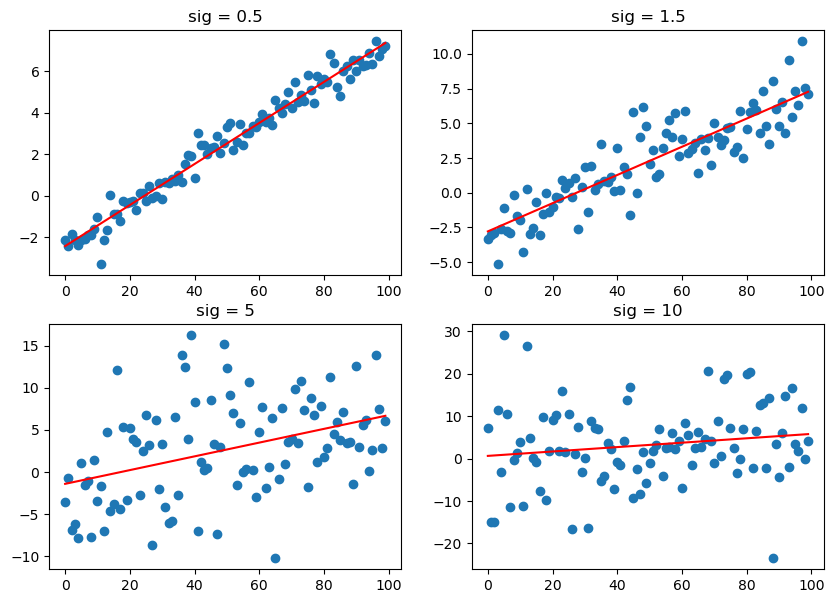

In [8]:
fig, ax = plt.subplots(2,2, figsize=(10,7))

ax[0,0].scatter(x, y_1)
ax[0,0].plot(x, reg1_y, color = 'r')
ax[0,0].set_title("sig = 0.5")

ax[0,1].scatter(x, y_2)
ax[0,1].plot(x, reg2_y, color = 'r')
ax[0,1].set_title("sig = 1.5")

ax[1,0].scatter(x, y_3)
ax[1,0].plot(x, reg3_y, color = 'r')
ax[1,0].set_title("sig = 5")

ax[1,1].scatter(x, y_4)
ax[1,1].plot(x, reg4_y, color = 'r')
ax[1,1].set_title("sig = 10")

plt.show()

### Question 1b:

What do you observe as we add noise to our generated dataset? How well are we able to recover the true parameters, `w_0_true` and `w_1_true` from the data as noise increases?

Enter in your answer here.

# Exercise 2
Read the California Housing Data from the `sample_data` on every collab instance:

In [1]:
import pandas as pd
train = pd.read_csv("sample_data/california_housing_train.csv")
test = pd.read_csv("sample_data/california_housing_test.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'sample_data/california_housing_train.csv'

This dataset contains features on census tracts in California in the early 1990’s. The target is the variable `median_house_value` of each census tract.

### Exercise 2a:
Plot a [scatter_plot matrix](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.plotting.scatter_matrix.html) using the training data. You may need to tune the `fig_size` argument to make the figure larger. 

In [ ]:
# Enter your code to plot the scatter_plot matrix here.

What variables appear to be correlated with `median_house_value`?

> Enter your answer here

What variables are not correlated with `median_house_value`?

> Enter your answer here

What features appear to be correlated with each other?

> Enter your answer here

### Exercise 2b
Fit a linear regression model using `sklearn`.
* Fit a few different models (each with different features).
* Evaluate the [mean_squared_error](https://scikit-learn.org/stable/modules/model_evaluation.html#mean-squared-error) of your models with both the training and test set.

In [ ]:
# Enter your code for exercise 2b here.

What did you observe? Which model yields the lowest test error?

> Enter your answer here

### Exercise 2c
Fit a linear regression using the `statsmodels` api.
* Print the model output using `print(results.summary())`

In [ ]:
#Enter your code for exercise 2c here.

Comment on which features appear to have the strongest relationship with `median_house_value`?

> Enter your answer here

Write a sentence interpreting the coefficient for `median_income`.

> Enter your answer here